In [13]:
import pandas as pd;
import seaborn as sns;
df=pd.read_csv("data.csv");
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
x=df.drop(columns=["charges"])
y=df["charges"]
x=pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes": 1, "no": 0})


x["age_smoker"] = x["age"] * x["smoker"]
x["bmi_smoker"] = x["bmi"] * x["smoker"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)


MSE for alpha=0.001:  20922599.87103596
MSE for alpha=0.1:  20921803.698431373
MSE for alpha=1:  20914832.635089133
MSE for alpha=2:  20908106.77995452
MSE for alpha=5:  20890881.000633497
MSE for alpha=10:  20872844.794796687
MSE for alpha=20:  20877828.53237883
MSE for alpha=30:  20937537.133939777
MSE for alpha=40:  21046489.29389078
MSE for alpha=50:  21196929.869608905
MSE for alpha=100:  22423172.686023258


<Axes: >

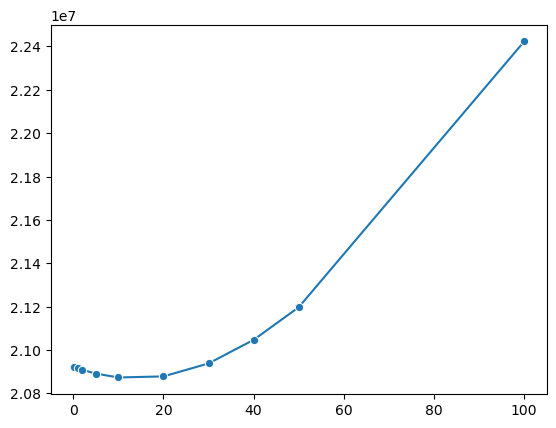

In [10]:
import seaborn as sns

alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(x_train, y_train)
    
    y_pred = lasso_model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha={a}: ", mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker="o")

In [14]:
from sklearn.linear_model import LassoCV
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
lassocv_model=LassoCV(
alphas=a,cv=5,max_iter=1000,random_state=42  
)
lassocv_model.fit(x_train,y_train)
print("best alpha",lassocv_model.alpha_)
y_pred=lassocv_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(mse)
r2=r2_score(y_pred,y_test)
print(r2)

best alpha 0.001
20922599.87103596
0.8508509197246666
